In [3]:
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
import ast

In [4]:
dataset = load_dataset("lukebarousse/data_jobs")
df = dataset["train"].to_pandas()

In [5]:
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda skill_list: ast.literal_eval(skill_list) if pd.notna(skill_list) else skill_list)

In [6]:
df = df[df['job_title_short'] == 'Data Analyst']

In [7]:
df = df.explode('job_skills')


In [8]:
skills_stats = df.groupby('job_skills').agg(
    skills_count=('job_skills', 'count'),
    median_salary=('salary_year_avg', 'median')                                                
)

skills_stats = skills_stats.sort_values(by='skills_count', ascending=False).head(10)

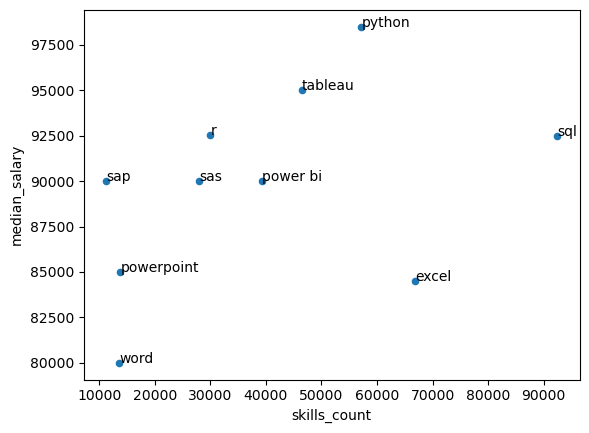

In [9]:
skills_stats.plot(kind='scatter', x='skills_count', y='median_salary')

for i, txt in enumerate(skills_stats.index):
    plt.text(skills_stats['skills_count'].iloc[i],skills_stats['median_salary'].iloc[i],txt)

plt.show()